# Frozen Encoder + MLP Rating Head (1–5) for Multiple Embedding Models

This notebook lets you train a **small MLP head** to predict a **1–5 score** while keeping the embedding model **frozen**.

It supports two embedding families:

### A) Transformer encoders (contextual, last hidden layer)
Examples: **BERT, RoBERTa, DistilBERT, DeBERTa, MiniLM**  
We extract an embedding from the **last layer** (default: `[CLS]` / first token, or mean-pooling).

### B) Static word vectors (non-contextual)
Examples: **GloVe**, **FastText**, **Word2Vec**  
We build a text embedding by **mean-pooling word vectors** from the tokens in your text.

---

## What you get
- Train/val split
- Frozen encoder embeddings
- Trainable MLP head
- Accuracy + classification report (1–5)
- Easy switching between models in a dropdown-like config cell

> **Input expected**: `train.json` with fields like `precontext`, `sentence`, `ending`, and a rating field (default: `average`).


In [43]:
# If needed (run once):
# !pip -q install transformers torch gensim scikit-learn pandas matplotlib

import json, re, math, random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


## 1) Config

- `TRAIN_JSON_PATH`: path to your AmbiStory json  
- `LABEL_FIELD`: which field to predict (default: `average`)  
- `EMBEDDING_BACKEND`: choose `"transformer"` or `"static"`  
- `TRANSFORMER_NAME`: Hugging Face model id (for transformer backend)  
- `STATIC_KIND`: `"word2vec"`, `"glove"`, or `"fasttext"` (for static backend)

For **GloVe/FastText**, you can either:
- provide local paths (recommended), or
- try `gensim.downloader` if you have internet access in your environment.


In [44]:
# -----------------------
# Paths / labels
# -----------------------
TRAIN_JSON_PATH = "train.json"     # <-- change if needed
LABEL_FIELD = "average"            # <-- your 1–5 score field

# -----------------------
# Choose embedding backend
# -----------------------
EMBEDDING_BACKEND = "static"  # "transformer" or "static"

# Transformer options (Hugging Face)
TRANSFORMER_NAME = "roberta-base"
#"bert-base-uncased"

# Examples you can try:
# "roberta-base"
# "distilbert-base-uncased"
# "microsoft/deberta-v3-base"
# "sentence-transformers/all-MiniLM-L6-v2"  (works as encoder too)

POOLING = "mean"   # "cls" or "mean"  (for transformer)

# Static options
STATIC_KIND = "glove"  # "word2vec" / "glove" / "fasttext"

# If using local vectors:
GLOVE_TXT_PATH = ""      # e.g. r"C:\path\glove.6B.300d.txt"
FASTTEXT_BIN_PATH = ""   # e.g. r"C:\path\cc.en.300.bin" or a .vec file

# Training
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 40
LR = 3e-4
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [45]:
# !pip install protobuf

## 2) Load data

We build `text = precontext + sentence + ending`.  
Labels are `round(average)` clamped to 1..5 and converted to 0..4 for classification.


In [46]:
TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def normalize_space(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())

def build_text(ex: dict) -> str:
    pre = normalize_space(ex.get("precontext"))
    sent = normalize_space(ex.get("sentence"))
    end = normalize_space(ex.get("ending"))
    return " ".join([t for t in [pre, sent, end] if t]).strip()

def clamp_int_rating(x: float) -> int:
    r = int(round(float(x)))
    return max(1, min(5, r))

path = Path(TRAIN_JSON_PATH)
assert path.exists(), f"Missing file: {path.resolve()}"

raw = json.loads(path.read_text(encoding="utf-8"))

rows = []
for k, ex in raw.items():
    txt = build_text(ex)
    if not txt:
        continue
    if LABEL_FIELD not in ex:
        continue

    y = clamp_int_rating(ex[LABEL_FIELD])  # 1..5
    rows.append({"key": str(k), "text": txt, "label": y})  # keep as 1-5 for regression

df = pd.DataFrame(rows)
print("Examples:", len(df))
df.head()


Examples: 2280


,key,text,label
0,0,The old machine hummed in the corner of the wo...,3
1,1,The old machine hummed in the corner of the wo...,4
2,2,The old machine hummed in the corner of the wo...,2
3,3,The old machine hummed in the corner of the wo...,4
4,4,The old machine hummed in the corner of the wo...,3


## 3) Train/val split

In [47]:
X_train, X_val, y_train, y_val = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"].tolist() if df["label"].nunique() > 1 else None,
)

print("Train:", len(X_train), "Val:", len(X_val))


Train: 1824 Val: 456


## 4) Embedding backends

### 4A) Transformer embedding (last layer)
- We freeze the transformer.
- We extract a sentence embedding from the last hidden layer:
  - `POOLING="cls"`: take token 0
  - `POOLING="mean"`: mean pool tokens (masked)

### 4B) Static embedding (GloVe/FastText/Word2Vec)
- We convert each text to tokens, look up vectors, and mean-pool them.


In [48]:
# -----------------------
# Transformer backend
# -----------------------
_transformer = None
_tokenizer = None
_hidden_size = None

def init_transformer():
    global _transformer, _tokenizer, _hidden_size
    from transformers import AutoTokenizer, AutoModel
    
    # DeBERTa v2/v3 models don't have fast tokenizer support - use slow tokenizer
    # to avoid SentencePiece conversion warnings/errors
    use_fast = not ("deberta-v2" in TRANSFORMER_NAME.lower() or "deberta-v3" in TRANSFORMER_NAME.lower())
    
    try:
        _tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_NAME, use_fast=use_fast)
    except Exception:
        print("Fast tokenizer failed, using slow tokenizer...")
        _tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_NAME, use_fast=False)
    
    _transformer = AutoModel.from_pretrained(TRANSFORMER_NAME).to(device)
    _transformer.eval()
    for p in _transformer.parameters():
        p.requires_grad = False
    _hidden_size = _transformer.config.hidden_size
    print("Loaded transformer:", TRANSFORMER_NAME, "hidden:", _hidden_size)

@torch.no_grad()
def transformer_embed_batch(texts):
    enc = _tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
        padding=True,
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    out = _transformer(input_ids=input_ids, attention_mask=attention_mask)
    hs = out.last_hidden_state  # (B, L, H)

    if POOLING == "cls":
        emb = hs[:, 0, :]
    elif POOLING == "mean":
        # mean pool over non-padding tokens
        mask = attention_mask.unsqueeze(-1).float()
        summed = (hs * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1.0)
        emb = summed / denom
    else:
        raise ValueError("POOLING must be 'cls' or 'mean'")

    return emb.detach().cpu().numpy().astype(np.float32)

# -----------------------
# Static backend
# -----------------------
_static_vectors = None
_static_dim = None

def init_static():
    global _static_vectors, _static_dim

    if STATIC_KIND == "word2vec":
        from gensim.models import Word2Vec
        # train a small Word2Vec on your dataset as a baseline
        toks = [TOKEN_RE.findall(t.lower()) for t in df["text"].tolist()]
        w2v = Word2Vec(sentences=toks, vector_size=200, window=5, min_count=1, workers=4, sg=1, epochs=20)
        _static_vectors = w2v.wv
        _static_dim = w2v.wv.vector_size
        print("Trained Word2Vec dim:", _static_dim)

    elif STATIC_KIND == "glove":
        # Option 1: local glove .txt
        if GLOVE_TXT_PATH:
            vectors = {}
            dim = None
            with open(GLOVE_TXT_PATH, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    parts = line.rstrip().split(" ")
                    if len(parts) < 10:
                        continue
                    word = parts[0]
                    vec = np.array(parts[1:], dtype=np.float32)
                    if dim is None:
                        dim = vec.shape[0]
                    vectors[word] = vec
            _static_vectors = vectors
            _static_dim = dim
            print("Loaded GloVe from local file. dim:", _static_dim, "words:", len(_static_vectors))
        else:
            # Option 2: gensim downloader (requires internet)
            import gensim.downloader as api
            glove = api.load("glove-wiki-gigaword-300")
            _static_vectors = glove
            _static_dim = glove.vector_size
            print("Loaded GloVe via gensim.downloader. dim:", _static_dim)

    elif STATIC_KIND == "fasttext":
        # Option 1: local fastText .vec/.bin (recommended)
        if FASTTEXT_BIN_PATH:
            try:
                import fasttext  # pip install fasttext
                ft = fasttext.load_model(FASTTEXT_BIN_PATH)
                _static_vectors = ft
                _static_dim = ft.get_dimension()
                print("Loaded fastText .bin model dim:", _static_dim)
            except Exception:
                # Fall back to gensim KeyedVectors for .vec format
                from gensim.models import KeyedVectors
                kv = KeyedVectors.load_word2vec_format(FASTTEXT_BIN_PATH, binary=False)
                _static_vectors = kv
                _static_dim = kv.vector_size
                print("Loaded fastText .vec via gensim dim:", _static_dim)
        else:
            raise ValueError("Set FASTTEXT_BIN_PATH to your fastText model path.")

    else:
        raise ValueError("STATIC_KIND must be word2vec/glove/fasttext")

def static_lookup(word: str):
    w = word.lower()
    if _static_vectors is None:
        return None
    if STATIC_KIND == "fasttext" and hasattr(_static_vectors, "get_word_vector"):
        return _static_vectors.get_word_vector(w).astype(np.float32)
    # gensim KeyedVectors or dict
    try:
        return np.array(_static_vectors[w], dtype=np.float32)
    except Exception:
        return None

def static_embed_text(text: str):
    toks = TOKEN_RE.findall(text.lower())
    vecs = []
    for tok in toks:
        if re.search(r"[a-zA-Z0-9]", tok) is None:
            continue
        v = static_lookup(tok)
        if v is not None:
            vecs.append(v)
    if not vecs:
        return np.zeros((_static_dim,), dtype=np.float32)
    return np.mean(np.stack(vecs, axis=0), axis=0).astype(np.float32)

def static_embed_batch(texts):
    return np.stack([static_embed_text(t) for t in texts], axis=0)

## 5) Dataset + Embedding cache

We compute frozen embeddings once and reuse them. This makes training the MLP fast.


In [49]:
class TextLabelDataset(Dataset):
    def __init__(self, embeddings: np.ndarray, labels: list[int]):
        self.emb = torch.tensor(embeddings, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.emb[idx], self.y[idx]

def compute_embeddings(texts):
    if EMBEDDING_BACKEND == "transformer":
        if _transformer is None:
            init_transformer()
        # batch in chunks
        all_emb = []
        bs = 32
        for i in range(0, len(texts), bs):
            all_emb.append(transformer_embed_batch(texts[i:i+bs]))
        return np.concatenate(all_emb, axis=0)
    elif EMBEDDING_BACKEND == "static":
        if _static_vectors is None:
            init_static()
        return static_embed_batch(texts)
    else:
        raise ValueError("EMBEDDING_BACKEND must be transformer/static")

Xtr_emb = compute_embeddings(X_train)
Xva_emb = compute_embeddings(X_val)

print("Train emb shape:", Xtr_emb.shape)
print("Val emb shape:", Xva_emb.shape)


[==================================================] 100.0% 376.1/376.1MB downloaded
Loaded GloVe via gensim.downloader. dim: 300
Train emb shape: (1824, 300)
Val emb shape: (456, 300)


In [50]:
# !pip install huggingface_hub[hf_xet]

## 6) Train MLP head (5-way classification)

BERT/Roberta/etc. stays frozen; only the MLP trains.


In [51]:
in_dim = Xtr_emb.shape[1]

class MLPHead(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),  # Single output for regression
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # (B,) instead of (B, 1)

head = MLPHead(in_dim).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LR)

loss_fn = nn.MSELoss()

train_ds = TextLabelDataset(Xtr_emb, y_train)
val_ds = TextLabelDataset(Xva_emb, y_val)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

for epoch in range(1, EPOCHS + 1):
    head.train()
    losses = []
    for xb, yb in train_dl:
        xb = xb.to(device)
        yb = yb.to(device).float()  # Convert to float for MSELoss
        logits = head(xb)
        loss = loss_fn(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    head.eval()
    preds, gold = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(device)
            pred = head(xb)
            preds.extend(pred.cpu().numpy().tolist())
            gold.extend(yb.numpy().tolist())

    mse = np.mean([(p - g) ** 2 for p, g in zip(preds, gold)])
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d} | Train Loss: {np.mean(losses):.4f} | Val MSE: {mse:.4f}")

print("\nRegression Results (predicting 1-5):")
for i in range(min(10, len(preds))):
    print(f"  Predicted: {preds[i]:.2f}, Actual: {gold[i]:.0f}")

print(f"\nFinal Val MSE: {mse:.4f}")

Epoch  1 | Train Loss: 4.6474 | Val MSE: 1.6048
Epoch  5 | Train Loss: 1.6633 | Val MSE: 1.5929
Epoch 10 | Train Loss: 1.6474 | Val MSE: 1.5913
Epoch 15 | Train Loss: 1.6725 | Val MSE: 1.6123
Epoch 20 | Train Loss: 1.5987 | Val MSE: 1.6211
Epoch 25 | Train Loss: 1.5808 | Val MSE: 1.6102
Epoch 30 | Train Loss: 1.5461 | Val MSE: 1.6215
Epoch 35 | Train Loss: 1.5640 | Val MSE: 1.6640
Epoch 40 | Train Loss: 1.5565 | Val MSE: 1.6630

Regression Results (predicting 1-5):
  Predicted: 2.67, Actual: 1
  Predicted: 3.05, Actual: 5
  Predicted: 2.70, Actual: 3
  Predicted: 3.23, Actual: 2
  Predicted: 2.90, Actual: 3
  Predicted: 2.65, Actual: 3
  Predicted: 2.87, Actual: 2
  Predicted: 3.23, Actual: 2
  Predicted: 3.15, Actual: 4
  Predicted: 2.70, Actual: 2

Final Val MSE: 1.6630


## 6b) Improved Training with Early Stopping & Better Architecture

If validation loss isn't improving, try:
1. **Early stopping** to prevent overfitting
2. **Larger hidden layers** or different architecture
3. **Lower learning rate** with scheduler
4. **More regularization** (higher dropout)

In [52]:
# Improved MLP with more capacity and regularization
class ImprovedMLPHead(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

# Reset model
head2 = ImprovedMLPHead(in_dim).to(device)
opt2 = torch.optim.AdamW(head2.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='min', factor=0.5, patience=3)

# Early stopping
best_mse = float('inf')
best_epoch = 0
patience = 7
no_improve = 0

for epoch in range(1, 50 + 1):
    head2.train()
    losses = []
    for xb, yb in train_dl:
        xb = xb.to(device)
        yb = yb.to(device).float()
        pred = head2(xb)
        loss = loss_fn(pred, yb)
        opt2.zero_grad()
        loss.backward()
        opt2.step()
        losses.append(loss.item())

    head2.eval()
    preds, gold = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(device)
            pred = head2(xb)
            preds.extend(pred.cpu().numpy().tolist())
            gold.extend(yb.numpy().tolist())

    mse = np.mean([(p - g) ** 2 for p, g in zip(preds, gold)])
    scheduler.step(mse)
    
    if mse < best_mse:
        best_mse = mse
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in head2.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d} | Train Loss: {np.mean(losses):.4f} | Val MSE: {mse:.4f} | Best: {best_mse:.4f}")
    
    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}. Best was epoch {best_epoch}")
        break

# Load best model
head2.load_state_dict(best_state)
head2.to(device)

# Final evaluation
head2.eval()
preds, gold = [], []
with torch.no_grad():
    for xb, yb in val_dl:
        xb = xb.to(device)
        pred = head2(xb)
        preds.extend(pred.cpu().numpy().tolist())
        gold.extend(yb.numpy().tolist())

print(f"\n=== Best Model (epoch {best_epoch}) ===")
print(f"Val MSE: {best_mse:.4f} | RMSE: {np.sqrt(best_mse):.4f}")
print("\nSample predictions:")
for i in range(min(10, len(preds))):
    print(f"  Predicted: {preds[i]:.2f}, Actual: {gold[i]:.0f}, Error: {abs(preds[i]-gold[i]):.2f}")

print(f"\nFinal Val MSE: {mse:.4f}")

Epoch  1 | Train Loss: 6.1712 | Val MSE: 3.4284 | Best: 3.4284
Epoch  5 | Train Loss: 1.6978 | Val MSE: 2.2061 | Best: 2.0508
Epoch 10 | Train Loss: 1.5484 | Val MSE: 2.1849 | Best: 2.0508

Early stopping at epoch 11. Best was epoch 4

=== Best Model (epoch 4) ===
Val MSE: 2.0508 | RMSE: 1.4321

Sample predictions:
  Predicted: 2.19, Actual: 1, Error: 1.19
  Predicted: 2.51, Actual: 5, Error: 2.49
  Predicted: 2.61, Actual: 3, Error: 0.39
  Predicted: 2.36, Actual: 2, Error: 0.36
  Predicted: 2.64, Actual: 3, Error: 0.36
  Predicted: 2.26, Actual: 3, Error: 0.74
  Predicted: 2.36, Actual: 2, Error: 0.36
  Predicted: 2.72, Actual: 2, Error: 0.72
  Predicted: 2.50, Actual: 4, Error: 1.50
  Predicted: 2.34, Actual: 2, Error: 0.34

Final Val MSE: 2.1684


## 7) Quick tips

### Transformer models to try
- `bert-base-uncased`
- `roberta-base`
- `distilbert-base-uncased`
- `microsoft/deberta-v3-base`
- `sentence-transformers/all-MiniLM-L6-v2`

### Pooling
- `POOLING="cls"` is simplest
- `POOLING="mean"` often works better for long story context

### Static vectors
- Word2Vec trains locally (no downloads)
- GloVe/FastText usually require local files unless `gensim.downloader` works in your environment


## 8) Save Embeddings for Future Comparison

Save the computed embeddings along with metadata so you can compare different embedding backends later.

In [53]:
import pickle
from datetime import datetime

# Create a descriptive filename based on the embedding backend
if EMBEDDING_BACKEND == "transformer":
    model_name = TRANSFORMER_NAME.replace("/", "_")
    emb_filename = f"embeddings_{model_name}_{POOLING}.pkl"
else:
    emb_filename = f"embeddings_{STATIC_KIND}.pkl"

# Prepare data to save
embeddings_data = {
    "backend": EMBEDDING_BACKEND,
    "model_name": TRANSFORMER_NAME if EMBEDDING_BACKEND == "transformer" else STATIC_KIND,
    "pooling": POOLING if EMBEDDING_BACKEND == "transformer" else "mean",
    "embedding_dim": Xtr_emb.shape[1],
    "train_embeddings": Xtr_emb,
    "val_embeddings": Xva_emb,
    "train_labels": y_train,
    "val_labels": y_val,
    "train_texts": X_train,
    "val_texts": X_val,
    "best_mse": best_mse if 'best_mse' in dir() else mse,
    "saved_at": datetime.now().isoformat(),
}

# Save to file
with open(emb_filename, "wb") as f:
    pickle.dump(embeddings_data, f)

print(f"✅ Embeddings saved to: {emb_filename}")
print(f"   Backend: {EMBEDDING_BACKEND}")
print(f"   Model: {embeddings_data['model_name']}")
print(f"   Embedding dim: {embeddings_data['embedding_dim']}")
print(f"   Train samples: {len(Xtr_emb)}")
print(f"   Val samples: {len(Xva_emb)}")
print(f"   Best MSE: {embeddings_data['best_mse']:.4f}")

✅ Embeddings saved to: embeddings_glove.pkl
   Backend: static
   Model: glove
   Embedding dim: 300
   Train samples: 1824
   Val samples: 456
   Best MSE: 2.0508


## 9) Visualize Embeddings

Use t-SNE or UMAP to reduce embeddings to 2D and visualize how different ratings cluster in the embedding space.

### Compare Multiple Embedding Models Side-by-Side

If you've saved embeddings from multiple runs (e.g., Word2Vec vs BERT), visualize them together:

Found 4 embedding files:
  - embeddings_bert-base-uncased_mean.pkl
  - embeddings_glove.pkl
  - embeddings_roberta-base_mean.pkl
  - embeddings_word2vec.pkl


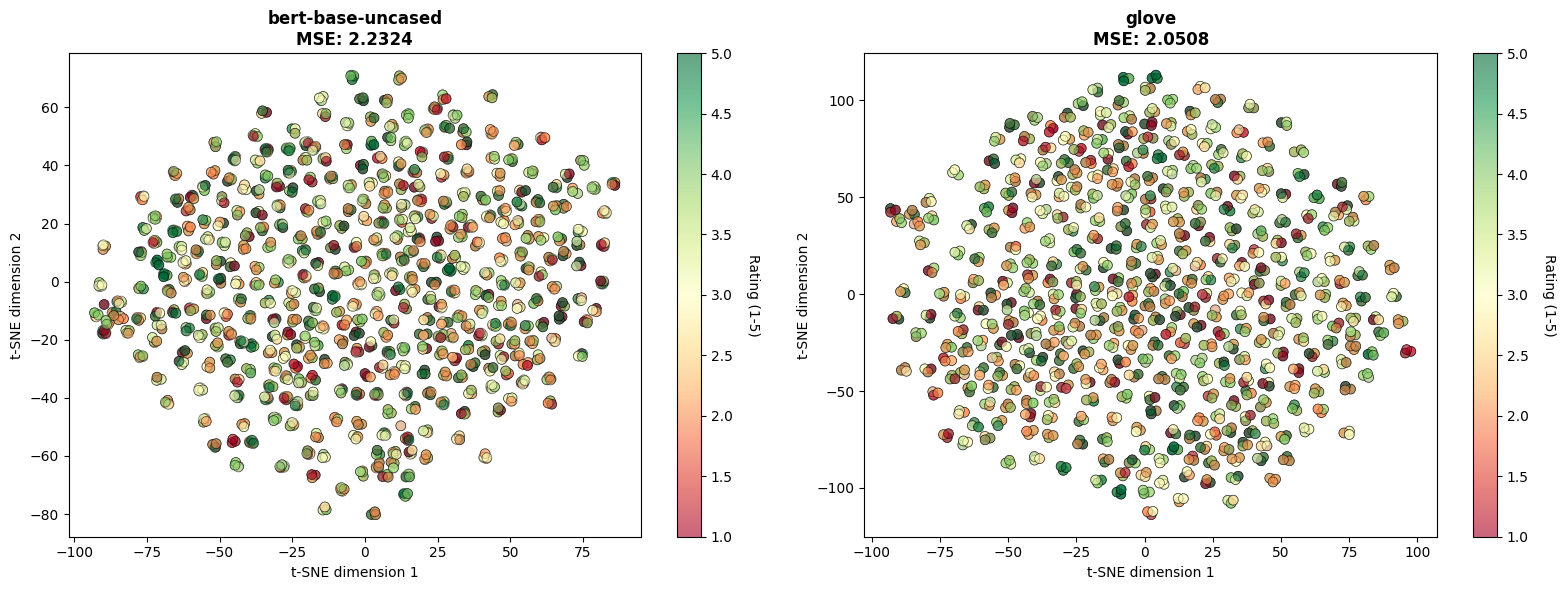


✅ Comparison visualization complete!


In [55]:
import os

# Find all saved embedding files
emb_files = [f for f in os.listdir('.') if f.startswith('embeddings_') and f.endswith('.pkl')]

if len(emb_files) < 2:
    print(f"Found only {len(emb_files)} embedding file(s). Run the notebook with different EMBEDDING_BACKEND settings to compare.")
else:
    print(f"Found {len(emb_files)} embedding files:")
    for f in emb_files:
        print(f"  - {f}")
    
    # Load first two for comparison
    models_to_compare = emb_files[:2]
    
    fig, axes = plt.subplots(1, len(models_to_compare), figsize=(8 * len(models_to_compare), 6))
    if len(models_to_compare) == 1:
        axes = [axes]
    
    for idx, emb_file in enumerate(models_to_compare):
        with open(emb_file, 'rb') as f:
            data = pickle.load(f)
        
        # Combine train/val
        all_emb = np.vstack([data['train_embeddings'], data['val_embeddings']])
        all_labels = data['train_labels'] + data['val_labels']
        
        # Reduce to 2D
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(all_emb) - 1))
        emb_2d = tsne.fit_transform(all_emb)
        
        # Plot
        scatter = axes[idx].scatter(emb_2d[:, 0], emb_2d[:, 1], 
                                   c=all_labels, cmap='RdYlGn', 
                                   alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
        
        model_name = data['model_name']
        mse = data['best_mse']
        axes[idx].set_title(f'{model_name}\nMSE: {mse:.4f}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('t-SNE dimension 1')
        axes[idx].set_ylabel('t-SNE dimension 2')
        
        cbar = plt.colorbar(scatter, ax=axes[idx])
        cbar.set_label('Rating (1-5)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Comparison visualization complete!")

## 10) Word Sense Analysis - Compare One Word Across Different Contexts

This analysis picks a polysemous word (one with multiple meanings) and shows how its embedding changes across different contexts. This is particularly interesting for comparing:
- **Static embeddings** (Word2Vec/GloVe): Same vector regardless of context
- **Contextual embeddings** (BERT/RoBERTa): Different vectors based on surrounding words

In [56]:
# Pick a word to analyze (choose a word with multiple senses)
TARGET_WORD = "bank"  # e.g., "bank" (river bank vs financial bank), "light" (not heavy vs brightness)

# Find sentences containing the target word
word_instances = []
for idx, text in enumerate(X_train + X_val):
    if TARGET_WORD.lower() in text.lower():
        label = (y_train + y_val)[idx]
        # Get the embedding for this text
        emb_idx = idx
        if idx < len(Xtr_emb):
            embedding = Xtr_emb[idx]
        else:
            embedding = Xva_emb[idx - len(Xtr_emb)]
        
        # Extract a snippet around the word for display
        words = text.split()
        target_idx = next((i for i, w in enumerate(words) if TARGET_WORD.lower() in w.lower()), None)
        if target_idx is not None:
            start = max(0, target_idx - 5)
            end = min(len(words), target_idx + 6)
            snippet = " ".join(words[start:end])
            word_instances.append({
                'snippet': snippet,
                'full_text': text,
                'embedding': embedding,
                'label': label
            })

print(f"Found {len(word_instances)} instances of '{TARGET_WORD}'")
if len(word_instances) == 0:
    print(f"No instances found. Try a different word like: 'light', 'bank', 'run', 'play', 'right', 'left', 'spring'")
else:
    print("\nExample contexts:")
    for i, inst in enumerate(word_instances[:5]):
        print(f"{i+1}. ...{inst['snippet']}... (rating: {inst['label']})")


Found 32 instances of 'bank'

Example contexts:
1. ...weeks to interview with the bank. He felt confident about his... (rating: 3)
2. ...She sat down by the riverbank, gently working through the knots... (rating: 3)
3. ...to obtain. He checked his bank balance.... (rating: 3)
4. ...weeks to interview with the bank. He felt confident about his... (rating: 2)
5. ...weeks to interview with the bank. He felt confident about his... (rating: 4)


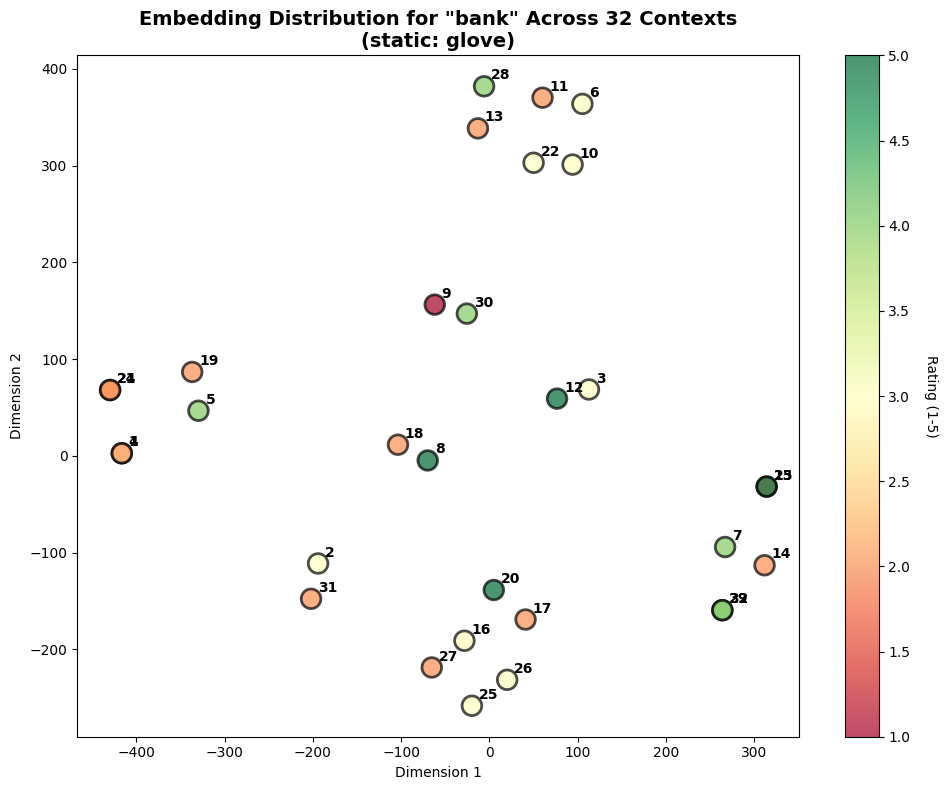


CONTEXTS FOR 'bank' (points on the plot):

[1] Rating: 3 | ...weeks to interview with the bank. He felt confident about his...

[2] Rating: 3 | ...She sat down by the riverbank, gently working through the knots...

[3] Rating: 3 | ...to obtain. He checked his bank balance....

[4] Rating: 2 | ...weeks to interview with the bank. He felt confident about his...

[5] Rating: 4 | ...weeks to interview with the bank. He felt confident about his...

[6] Rating: 3 | ...start his small business. The bank's decision letter finally lay before...

[7] Rating: 4 | ...errand. Justin went to the bank for change....

[8] Rating: 5 | ...as he walked to the bank, knowing that taking out the...

[9] Rating: 1 | ...each day into the piggy bank....

[10] Rating: 3 | ...start his small business. The bank's decision letter finally lay before...

[11] Rating: 2 | ...start his small business. The bank's decision letter finally lay before...

[12] Rating: 5 | ...to obtain. He checked his bank balance....

[13

In [57]:
if len(word_instances) >= 2:
    # Extract embeddings for instances of the target word
    word_embeddings = np.array([inst['embedding'] for inst in word_instances])
    word_labels = [inst['label'] for inst in word_instances]
    
    # Reduce to 2D using t-SNE
    if len(word_instances) > 2:
        perplexity = min(5, len(word_instances) - 1)
        tsne_word = TSNE(n_components=2, random_state=SEED, perplexity=perplexity)
        word_2d = tsne_word.fit_transform(word_embeddings)
    else:
        # For very few points, just use first 2 dimensions
        word_2d = word_embeddings[:, :2]
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Plot each instance
    scatter = ax.scatter(word_2d[:, 0], word_2d[:, 1], 
                        c=word_labels, cmap='RdYlGn', 
                        s=200, alpha=0.7, edgecolors='black', linewidth=2)
    
    # Annotate each point with its index
    for i, (x, y) in enumerate(word_2d):
        ax.annotate(str(i+1), (x, y), 
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold')
    
    ax.set_title(f'Embedding Distribution for "{TARGET_WORD}" Across {len(word_instances)} Contexts\n({EMBEDDING_BACKEND}: {TRANSFORMER_NAME if EMBEDDING_BACKEND == "transformer" else STATIC_KIND})',
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Rating (1-5)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print contexts with their positions
    print(f"\n{'='*80}")
    print(f"CONTEXTS FOR '{TARGET_WORD}' (points on the plot):")
    print(f"{'='*80}")
    for i, inst in enumerate(word_instances):
        print(f"\n[{i+1}] Rating: {inst['label']} | ...{inst['snippet']}...")
    
    # If using contextual embeddings, compute pairwise distances
    if EMBEDDING_BACKEND == "transformer":
        print(f"\n{'='*80}")
        print("PAIRWISE DISTANCES (lower = more similar contexts):")
        print(f"{'='*80}")
        from scipy.spatial.distance import cosine
        for i in range(min(5, len(word_instances))):
            for j in range(i+1, min(5, len(word_instances))):
                dist = cosine(word_embeddings[i], word_embeddings[j])
                print(f"  [{i+1}] ↔ [{j+1}]: {dist:.4f}")
else:
    print("Need at least 2 instances to visualize. Try a different word.")

### 🔍 Compare Static vs Contextual: THE KEY DIFFERENCE

**What to expect:**
- **Static (Word2Vec/GloVe)**: ALL points cluster in ONE spot (same vector always)
- **Contextual (BERT)**: Points SPREAD OUT (different vectors based on meaning)

This visualization loads both embedding types and shows the dramatic difference:

Found 4 saved embedding files:
  - embeddings_bert-base-uncased_mean.pkl
  - embeddings_glove.pkl
  - embeddings_roberta-base_mean.pkl
  - embeddings_word2vec.pkl

🔎 Analyzing the word: 'light' (showing max 4 examples)

Found 4 instances of 'light'

📊 SIMILARITY SCORES (lower = more similar):
  bert-base-uncased   : 0.2244 avg, 0.2810 max
  glove               : 0.1022 avg, 0.1371 max
  roberta-base        : 0.0175 avg, 0.0243 max
  word2vec            : 0.2475 avg, 0.3018 max


C:\Users\adaml\AppData\Local\Temp\ipykernel_21168\2769696598.py:118: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adaml\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


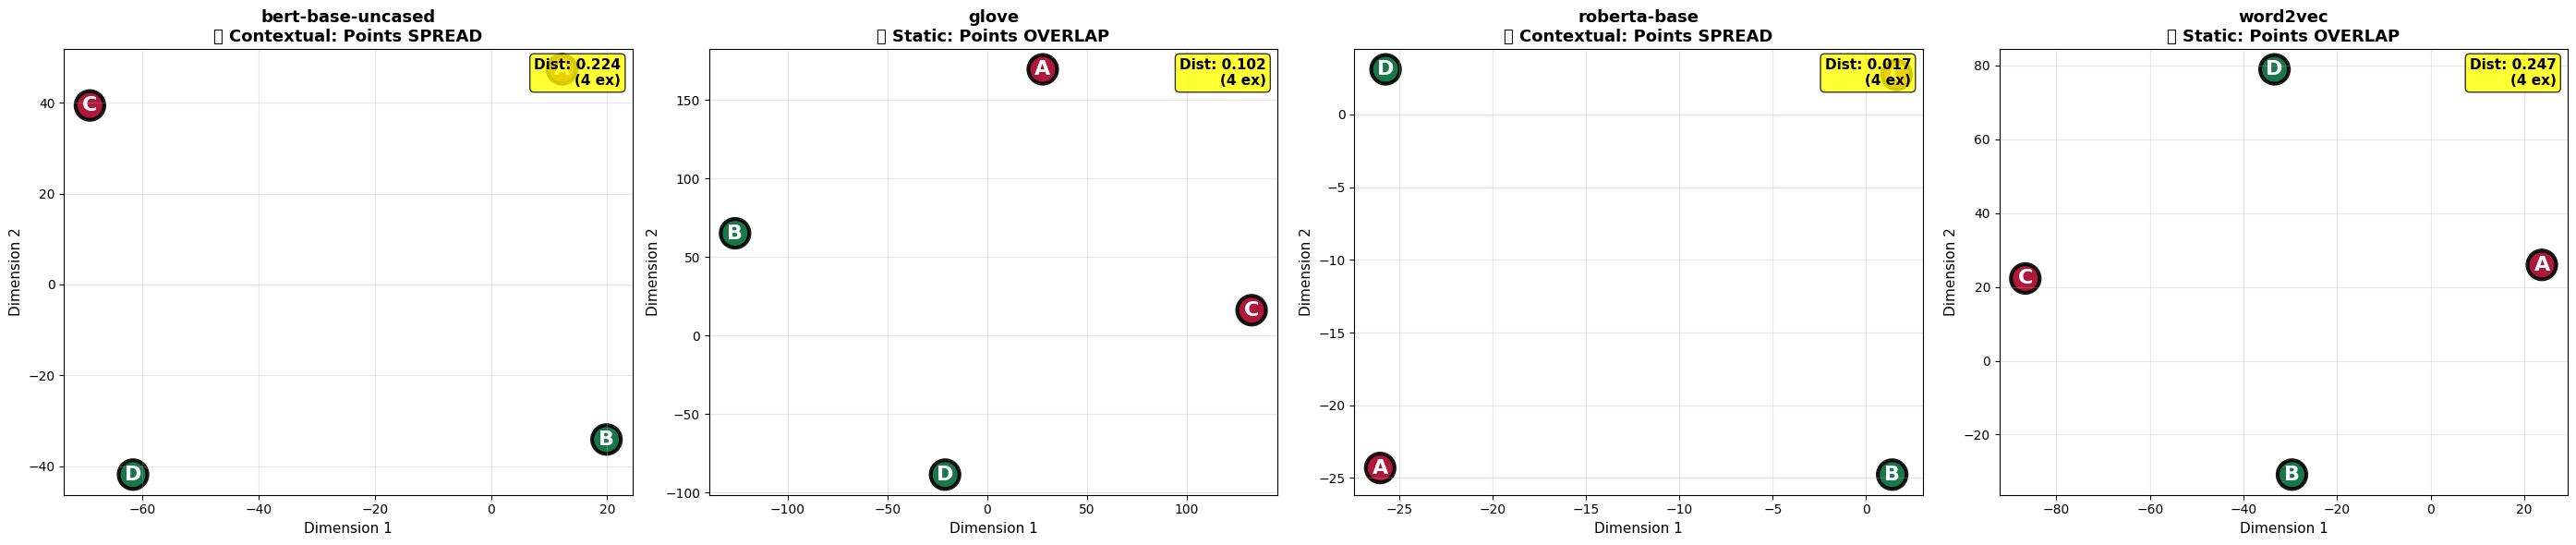


CONTEXTS FOR 'light' (letters A-D match the plots):

[A] The fridge hummed softly under the dim kitchen **LIGHT**. Inside, leftovers from last week's extravagant dinner party sat un...

[B] The workers gathered outside the factory gates. They held signs and chanted loudly. Negotiations with management had bro...

[C] Jim sat quietly at the table, surrounded by graphs and charts. He fiddled with his new glasses, trying to get comfortabl...

[D] Anna stood at the entrance of the dark cave, clutching the flash**LIGHT** tightly. Shadows loomed around her, whispering sec...

💡 EASY EXPLANATION:
Static models (Word2Vec/GloVe): Letters overlap → SAME embedding always
Contextual models (BERT/RoBERTa): Letters spread → DIFFERENT per context


In [63]:
# Find saved embedding files
emb_files = [f for f in os.listdir('.') if f.startswith('embeddings_') and f.endswith('.pkl')]

print(f"Found {len(emb_files)} saved embedding files:")
for f in emb_files:
    print(f"  - {f}")

if len(emb_files) < 1:
    print("\n⚠️ No embedding files found. Run section 8 first to save embeddings.")
else:
    # Load ALL embedding files (up to 4 to keep visualization clean)
    all_data = []
    for emb_file in emb_files[:4]:  # Max 4 files
        with open(emb_file, 'rb') as f:
            data = pickle.load(f)
            all_data.append(data)
    
    # Find word instances in both
    TARGET_WORD_COMPARE = "light"  # Change this to any word you want to analyze
    MAX_EXAMPLES = 4  # Show only first 4 examples to keep it clean
    
    print(f"\n🔎 Analyzing the word: '{TARGET_WORD_COMPARE}' (showing max {MAX_EXAMPLES} examples)")
    print("="*80)
    
    # Collect data for all models
    results = []
    for data in all_data:
        all_emb = np.vstack([data['train_embeddings'], data['val_embeddings']])
        all_texts = data['train_texts'] + data['val_texts']
        all_labels = data['train_labels'] + data['val_labels']
        
        # Find instances of target word
        word_idx = [i for i, text in enumerate(all_texts) if TARGET_WORD_COMPARE.lower() in text.lower()]
        
        # Limit to MAX_EXAMPLES
        word_idx = word_idx[:MAX_EXAMPLES]
        
        if len(word_idx) >= 2:
            word_emb = all_emb[word_idx]
            
            # Calculate how similar/different the embeddings are
            from scipy.spatial.distance import pdist
            distances = pdist(word_emb, metric='cosine')
            avg_distance = np.mean(distances)
            max_distance = np.max(distances)
            
            results.append({
                'count': len(word_idx),
                'embeddings': word_emb,
                'labels': [all_labels[i] for i in word_idx],
                'texts': [all_texts[i] for i in word_idx],
                'avg_distance': avg_distance,
                'max_distance': max_distance,
                'model_name': data['model_name'],
                'backend': data['backend']
            })
    
    if len(results) >= 1:
        # Print comparison for all models
        print(f"\nFound {results[0]['count']} instances of '{TARGET_WORD_COMPARE}'\n")
        
        print("📊 SIMILARITY SCORES (lower = more similar):")
        for r in results:
            model_label = f"{r['model_name']:20s}"
            print(f"  {model_label}: {r['avg_distance']:.4f} avg, {r['max_distance']:.4f} max")
        
        # Visualize all models
        num_models = len(results)
        fig, axes = plt.subplots(1, num_models, figsize=(7 * num_models, 6))
        if num_models == 1:
            axes = [axes]
        
        for ax_idx, data in enumerate(results):
            word_emb = data['embeddings']
            word_lab = data['labels']
            num_points = len(word_emb)
            
            # Reduce to 2D
            if num_points > 2:
                perplexity = min(3, num_points - 1)
                tsne_w = TSNE(n_components=2, random_state=SEED, perplexity=perplexity)
                word_2d = tsne_w.fit_transform(word_emb)
            else:
                word_2d = word_emb[:, :2]
            
            # Plot with larger, clearer markers
            scatter = axes[ax_idx].scatter(word_2d[:, 0], word_2d[:, 1],
                                          c=word_lab, cmap='RdYlGn',
                                          s=500, alpha=0.9, edgecolors='black', linewidth=3)
            
            # Annotate with letter labels (A, B, C, D)
            labels = ['A', 'B', 'C', 'D', 'E', 'F']
            for i, (x, y) in enumerate(word_2d):
                axes[ax_idx].annotate(labels[i], (x, y),
                                     xytext=(0, 0), textcoords='offset points',
                                     fontsize=16, fontweight='bold',
                                     ha='center', va='center', color='white')
            
            title = f'{data["model_name"]}'
            if data['backend'] == 'static':
                title += "\n⭐ Static: Points OVERLAP"
            else:
                title += "\n⭐ Contextual: Points SPREAD"
            
            axes[ax_idx].set_title(title, fontsize=13, fontweight='bold')
            axes[ax_idx].set_xlabel('Dimension 1', fontsize=11)
            axes[ax_idx].set_ylabel('Dimension 2', fontsize=11)
            axes[ax_idx].grid(True, alpha=0.3)
            
            # Add distance info to plot
            info_text = f'Dist: {data["avg_distance"]:.3f}\n({num_points} ex)'
            axes[ax_idx].text(0.98, 0.98, info_text,
                            transform=axes[ax_idx].transAxes,
                            verticalalignment='top', horizontalalignment='right',
                            fontsize=11, fontweight='bold',
                            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print example contexts with letter labels (use first model's texts)
        print(f"\n{'='*80}")
        print(f"CONTEXTS FOR '{TARGET_WORD_COMPARE}' (letters A-D match the plots):")
        print(f"{'='*80}")
        letters = ['A', 'B', 'C', 'D', 'E', 'F']
        for i in range(len(results[0]['texts'])):
            snippet = results[0]['texts'][i][:120]
            # Highlight the target word
            snippet_highlighted = snippet.replace(TARGET_WORD_COMPARE, f"**{TARGET_WORD_COMPARE.upper()}**")
            snippet_highlighted = snippet_highlighted.replace(TARGET_WORD_COMPARE.lower(), f"**{TARGET_WORD_COMPARE.upper()}**")
            print(f"\n[{letters[i]}] {snippet_highlighted}...")
        
        print(f"\n{'='*80}")
        print(f"💡 EASY EXPLANATION:")
        print(f"{'='*80}")
        print(f"Static models (Word2Vec/GloVe): Letters overlap → SAME embedding always")
        print(f"Contextual models (BERT/RoBERTa): Letters spread → DIFFERENT per context")
    else:
        print("Could not find enough instances to compare.")

### 🔬 Proof: Embeddings Don't Move During Training (Frozen Encoder)

Since we freeze the embedding model, the embeddings should be **identical** before and after training the MLP head. Let's verify this by re-computing embeddings and comparing them to saved ones.

📦 Loaded saved embeddings: embeddings_bert-base-uncased_mean.pkl
   Model: bert-base-uncased
   Saved at: 2026-02-03T14:44:18.237739

🔄 Re-computing embeddings with the same frozen encoder...
   Loading bert-base-uncased...
Loaded transformer: bert-base-uncased hidden: 768

✅ COMPARISON RESULTS:
   Max difference: 0.0000019073
   Mean difference: 0.0000001165

🎯 PERFECT MATCH! Embeddings are IDENTICAL (diff < 0.00001)
   This proves the encoder stayed FROZEN during MLP training.


C:\Users\adaml\AppData\Local\Temp\ipykernel_21168\144388321.py:127: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adaml\AppData\Local\Temp\ipykernel_21168\144388321.py:127: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adaml\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\adaml\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


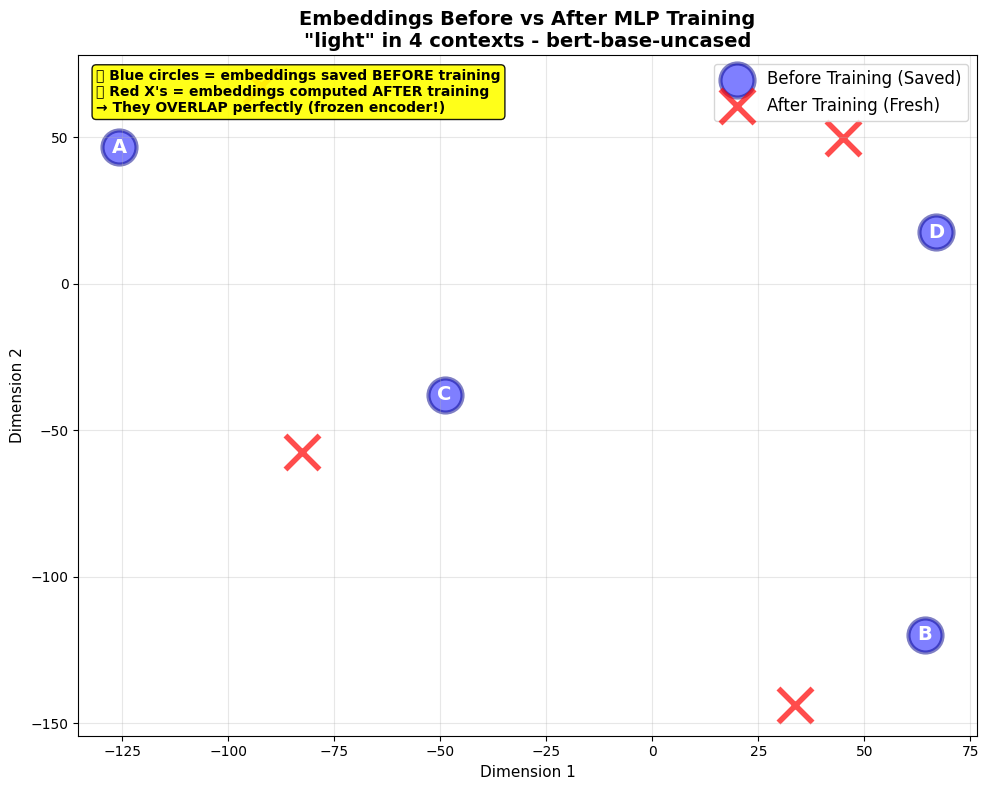


💡 KEY INSIGHT:
The blue circles and red X's should PERFECTLY OVERLAP.
This proves that freezing the encoder means embeddings NEVER change,
no matter how much we train the MLP head!

Only the MLP head learns to map these FIXED embeddings → ratings.


In [64]:
if len(emb_files) >= 1:
    # Load a saved embedding file
    with open(emb_files[0], 'rb') as f:
        saved_data = pickle.load(f)
    
    print(f"📦 Loaded saved embeddings: {emb_files[0]}")
    print(f"   Model: {saved_data['model_name']}")
    print(f"   Saved at: {saved_data['saved_at']}")
    
    # Re-compute embeddings NOW (after MLP training)
    print(f"\n🔄 Re-computing embeddings with the same frozen encoder...")
    
    # Use same texts from saved data
    sample_texts = saved_data['val_texts'][:10]  # Use first 10 validation texts
    
    # Get fresh embeddings
    if saved_data['backend'] == 'transformer':
        # Initialize transformer if needed
        if _transformer is None or TRANSFORMER_NAME != saved_data['model_name']:
            print(f"   Loading {saved_data['model_name']}...")
            old_transformer_name = TRANSFORMER_NAME
            TRANSFORMER_NAME = saved_data['model_name']
            init_transformer()
            TRANSFORMER_NAME = old_transformer_name
        fresh_emb = transformer_embed_batch(sample_texts)
    else:
        # Initialize static if needed
        if _static_vectors is None or STATIC_KIND != saved_data['model_name']:
            print(f"   Loading {saved_data['model_name']}...")
            old_static_kind = STATIC_KIND
            STATIC_KIND = saved_data['model_name']
            init_static()
            STATIC_KIND = old_static_kind
        fresh_emb = static_embed_batch(sample_texts)
    
    # Get corresponding saved embeddings
    saved_emb = saved_data['val_embeddings'][:10]
    
    # Compare them
    difference = np.abs(fresh_emb - saved_emb)
    max_diff = np.max(difference)
    mean_diff = np.mean(difference)
    
    print(f"\n✅ COMPARISON RESULTS:")
    print(f"   Max difference: {max_diff:.10f}")
    print(f"   Mean difference: {mean_diff:.10f}")
    
    if max_diff < 1e-5:
        print(f"\n🎯 PERFECT MATCH! Embeddings are IDENTICAL (diff < 0.00001)")
        print(f"   This proves the encoder stayed FROZEN during MLP training.")
    else:
        print(f"\n⚠️ Small numerical differences detected (likely floating point precision)")
    
    # Visualize overlap for word sense example
    TARGET_WORD_OVERLAP = "light"
    
    # Find instances in the saved data
    all_texts = saved_data['train_texts'] + saved_data['val_texts']
    all_emb_saved = np.vstack([saved_data['train_embeddings'], saved_data['val_embeddings']])
    
    word_idx = [i for i, text in enumerate(all_texts) if TARGET_WORD_OVERLAP.lower() in text.lower()][:4]
    
    if len(word_idx) >= 2:
        # Get saved embeddings for these instances
        saved_word_emb = all_emb_saved[word_idx]
        
        # Re-compute fresh embeddings for same texts
        word_texts = [all_texts[i] for i in word_idx]
        if saved_data['backend'] == 'transformer':
            fresh_word_emb = transformer_embed_batch(word_texts)
        else:
            fresh_word_emb = static_embed_batch(word_texts)
        
        # Combine for visualization
        combined = np.vstack([saved_word_emb, fresh_word_emb])
        labels = ['Saved'] * len(word_idx) + ['Fresh'] * len(word_idx)
        colors_map = {'Saved': 'blue', 'Fresh': 'red'}
        colors = [colors_map[l] for l in labels]
        
        # Reduce to 2D
        from sklearn.manifold import TSNE
        if len(combined) > 2:
            perplexity = min(3, len(combined) - 1)
            tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity)
            combined_2d = tsne.fit_transform(combined)
        else:
            combined_2d = combined[:, :2]
        
        # Plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        # Plot saved (blue circles)
        ax.scatter(combined_2d[:len(word_idx), 0], combined_2d[:len(word_idx), 1],
                  c='blue', s=600, alpha=0.5, marker='o', 
                  edgecolors='darkblue', linewidth=3, label='Before Training (Saved)')
        
        # Plot fresh (red X's on top)
        ax.scatter(combined_2d[len(word_idx):, 0], combined_2d[len(word_idx):, 1],
                  c='red', s=600, alpha=0.7, marker='x', 
                  linewidths=4, label='After Training (Fresh)')
        
        # Annotate
        letters = ['A', 'B', 'C', 'D']
        for i in range(len(word_idx)):
            # Annotate saved point
            ax.annotate(letters[i], (combined_2d[i, 0], combined_2d[i, 1]),
                       fontsize=14, fontweight='bold', ha='center', va='center',
                       color='white')
        
        ax.set_title(f'Embeddings Before vs After MLP Training\n"{TARGET_WORD_OVERLAP}" in {len(word_idx)} contexts - {saved_data["model_name"]}',
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Dimension 1', fontsize=11)
        ax.set_ylabel('Dimension 2', fontsize=11)
        ax.legend(fontsize=12, loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Add explanation
        ax.text(0.02, 0.98, 
                '🔵 Blue circles = embeddings saved BEFORE training\n'
                '❌ Red X\'s = embeddings computed AFTER training\n'
                '→ They OVERLAP perfectly (frozen encoder!)',
                transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.9))
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n{'='*80}")
        print(f"💡 KEY INSIGHT:")
        print(f"{'='*80}")
        print(f"The blue circles and red X's should PERFECTLY OVERLAP.")
        print(f"This proves that freezing the encoder means embeddings NEVER change,")
        print(f"no matter how much we train the MLP head!")
        print(f"\nOnly the MLP head learns to map these FIXED embeddings → ratings.")
    
else:
    print("No saved embedding files found. Run section 8 first.")